# Thermodynamic diagram
We create a thermo diagram as described in p.63, ch.3 of the book by R. Stull *Practical Meteorology*

In [46]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [2]:
def p_theta(T, theta):
    T_0 = 273.15
    K = T + T_0
    theta_k = theta + T_0
    R_d = 287.08 # J/(KgK) gas constant for dry air
    c_p = 1004 # J(KgK) specific heat for dry air at constant pressure
    p_0 = 100 # kPa 
    p = p_0 / (theta_k / K) ** (c_p / R_d)
    return p

In [32]:
t_diagrams = [] 
T = np.linspace(-60, 60)
for theta in range(-60,60, 10):
    p = p_theta(T, theta)
    t_diagrams.append(p)

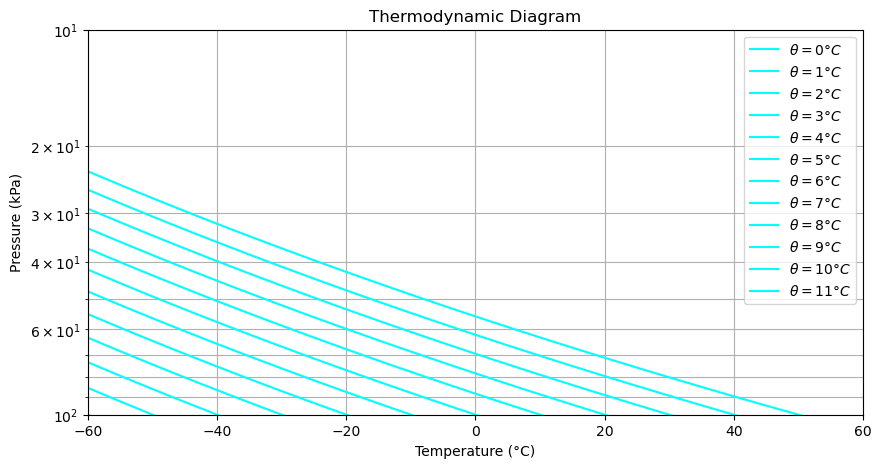

In [36]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()
ax.grid(visible=True, which='major')
ax.grid(axis='both', visible=True, which='minor')
ax.yaxis.set_inverted(True)
ax.set_ylim(100, 10)
ax.set_xlim(-60, 60)
ax.set_title("Thermodynamic Diagram")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Pressure (kPa)")
for i in range(0, len(t_diagrams)):
    ax.semilogy(T, t_diagrams[i], color='cyan', label='$\\theta = ' + str(i) + ' °C$')
ax.legend();

In [40]:
import metpy.calc as mpcalc
from metpy.plots import SkewT
from metpy.units import units

# 1. Generate or import sample sounding data
# Pressure must go from high (surface) to low (top of atmosphere)
p = np.array([1000, 925, 850, 700, 500, 400, 300, 250, 200, 150, 100]) * units.hPa
T = np.array([25, 20, 15, 5, -12, -23, -41, -52, -55, -56, -54]) * units.degC
Td = np.array([18, 14, 8, -2, -22, -35, -55, -65, -73, -80, -85]) * units.degC

# Wind components for the barbs
wind_speed = np.array([10, 15, 20, 30, 45, 55, 70, 85, 90, 80, 60]) * units.knots
wind_dir = np.array([180, 190, 210, 230, 250, 260, 270, 270, 280, 280, 290]) * units.degrees
u, v = mpcalc.wind_components(wind_speed, wind_dir)

In [51]:
def plot_thermodiagram(p, variable):
    # 2. Set up the figure and SkewT object
    fig = plt.figure(figsize=(9, 9))
    # 'rotation=45' controls the slant of the temperature lines
    skew = SkewT(fig, rotation=45)

    # 3. Plot the environmental profiles
    # Note: MetPy requires (pressure, variable) order for plotting
    skew.plot(p, variable, 'r', linewidth=2, label='Temperature')
    #skew.plot(p, Td, 'g', linewidth=2, label='Dewpoint')

    # 4. Plot wind barbs on the right axis
    #skew.plot_barbs(p, u, v)

    # 5. Add standard thermodynamic background lines
    skew.plot_dry_adiabats(colors='orange', alpha=0.4, linewidths=1)
    skew.plot_moist_adiabats(colors='blue', alpha=0.4, linewidths=1)
    skew.plot_mixing_lines(colors='green', alpha=0.3, linewidths=1, linestyle=':')

    # 6. Customize axes limits and labels
    skew.ax.set_xlim(-40, 40)
    skew.ax.set_ylim(1050, 100) # Flipped so high pressure is at the bottom

    plt.title('Skew-T ln P Diagram', fontsize=14, fontweight='bold')
    skew.ax.set_xlabel('Temperature (°C)')
skew.ax.set_ylabel('Pressure (hPa)')
skew.ax.legend();

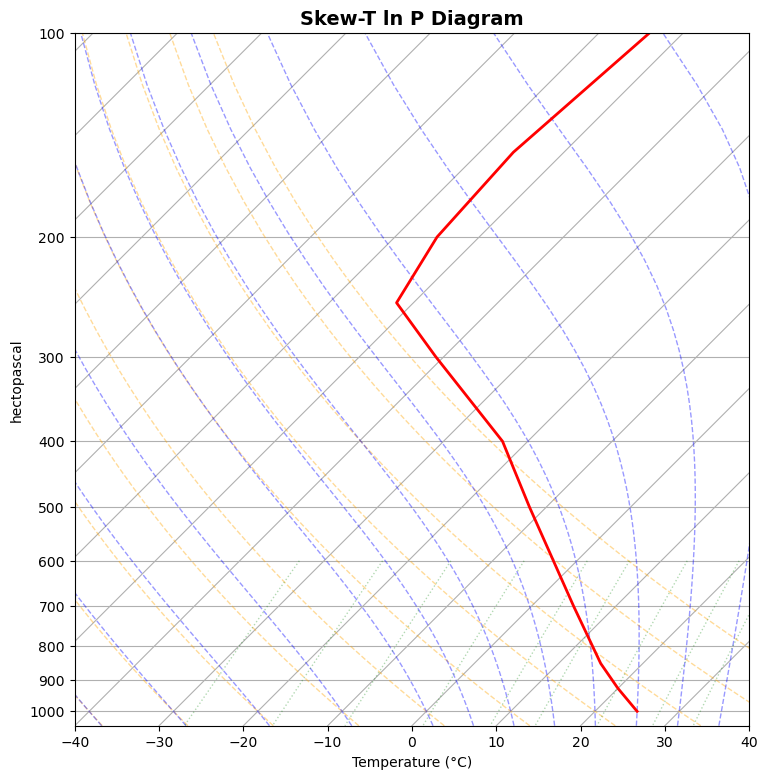

In [52]:
plot_thermodiagram(p, T)

In [49]:
radiosonde_path = 'data/pratica_di_mare/2026061100-16245.csv'
radiosonde_df = pd.read_csv(radiosonde_path, index_col=0)
radiosonde_df.head()

,geopotential height_m,temperature_C,dew point temperature_C,ice point temperature_C,relative humidity_%,humidity wrt ice_%,mixing ratio_g/kg,wind direction_degree,wind speed_m/s
pressure_hPa,,,,,,,,,
1011.0,32,20.4,19.6,19.6,95,95,14.33,0,0.0
1004.0,94,22.2,19.5,19.5,85,85,14.35,255,2.0
1000.0,130,22.0,20.0,20.0,88,88,14.87,195,3.1
954.0,539,18.6,18.1,18.1,97,97,13.82,241,5.0
950.0,575,18.4,17.4,17.4,93,93,13.23,245,5.2


In [70]:
rs_pressure = radiosonde_df.index.to_numpy() * units.hPa

In [61]:
rs_temperature = radiosonde_df['temperature_C'].to_numpy() * units.degC

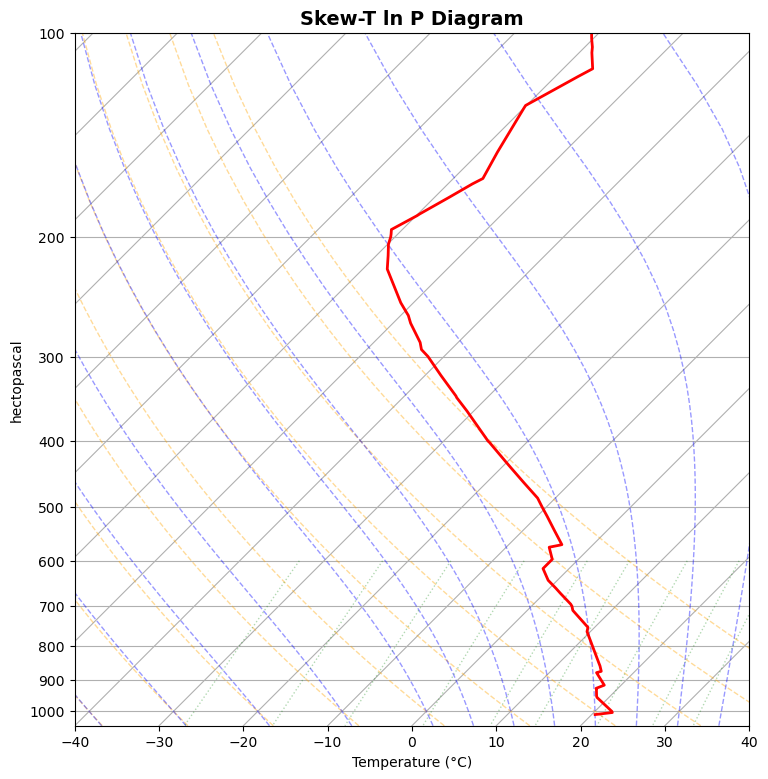

In [71]:
plot_thermodiagram(rs_pressure, rs_temperature)

## References and datasets
* [University of Wyoming Atmospheric Science Radiosonde Archive](https://weather.uwyo.edu/upperair/sounding.shtml)
* [Aeronautica Militare Italiana - Il Servizio di Radiosondaggio automatico dell'atmosfera](https://www.meteoam.it/it/autosonda)
* [VAISALA - Radiosonde RS41-SG](https://docs.vaisala.com/v/u/B211321EN-L/en-US)
* [Copernicus In-Situ](https://insitu.copernicus.eu/)
* [Copernicus In-Situ Data Providers](https://insitu.copernicus.eu/state-of-play/data-providers)
* [WMO - Global Observing System](https://wmo.int/activities/global-observing-system-gos/global-observing-system-gos)
* [WMO Oscar Surface](https://oscar.wmo.int/surface/#/)